[i] Читаем CSV...
[i] Inferred delimiter: ';'
[i] Прочитано. Колонки: ['datetime', 'Accelerometer1RMS', 'Accelerometer2RMS', 'Current', 'Pressure', 'Temperature', 'Thermocouple', 'Voltage', 'Volume Flow RateRMS', 'anomaly', 'changepoint']
[i] Выбрали колонку с значениями: 'Thermocouple'  | колонка с датой: 'datetime'
[i] Удалено строк без y: 0
[i] Превью ряда:
                   ds        y
0 2020-03-09 12:34:37  24.9122
1 2020-03-09 12:34:38  24.9038
2 2020-03-09 12:34:39  24.9055
3 2020-03-09 12:34:40  24.9110
4 2020-03-09 12:34:41  24.9110


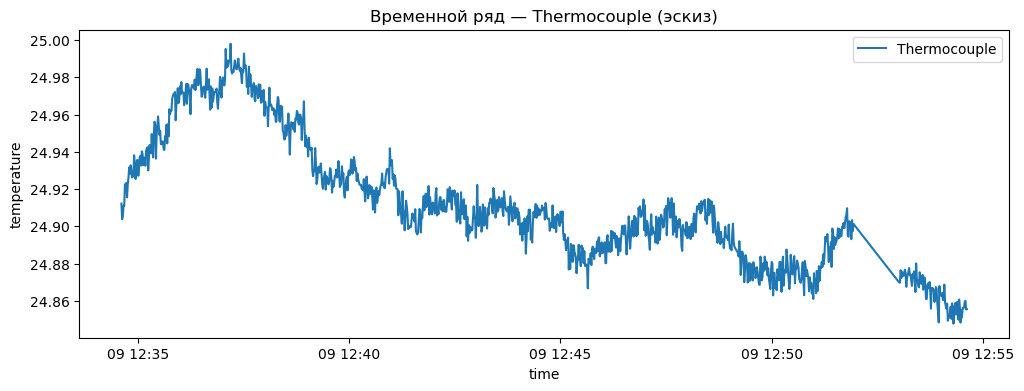

[i] Всего точек: 1094, train: 875, test: 219
[i] Метрики: RMSE (основная), MAE (доп.)


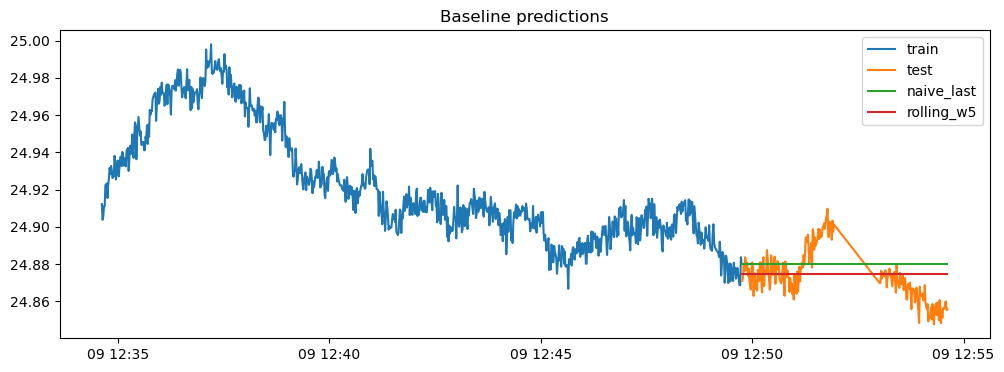

[i] Baseline metrics:
             model      rmse       mae
0       naive_last  0.014578  0.012105
1  rolling_mean_w5  0.013223  0.010319

[i] ADF test on train (H0: единичный корень - нестационарность)
ADF statistic = -0.5593, p-value = 0.8799
=> Ряд нестационарен (не отклоняем H0).


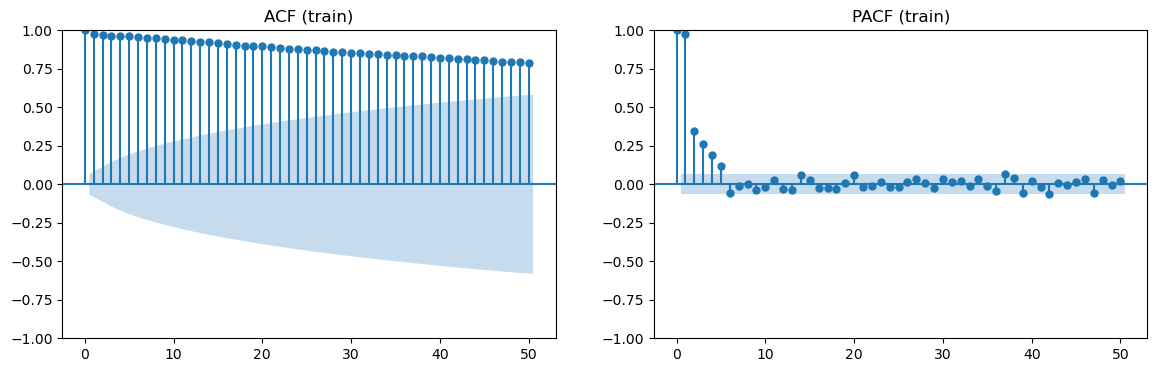


[i] ADF test on 1st difference
ADF statistic = -24.2943, p-value = 0.0000


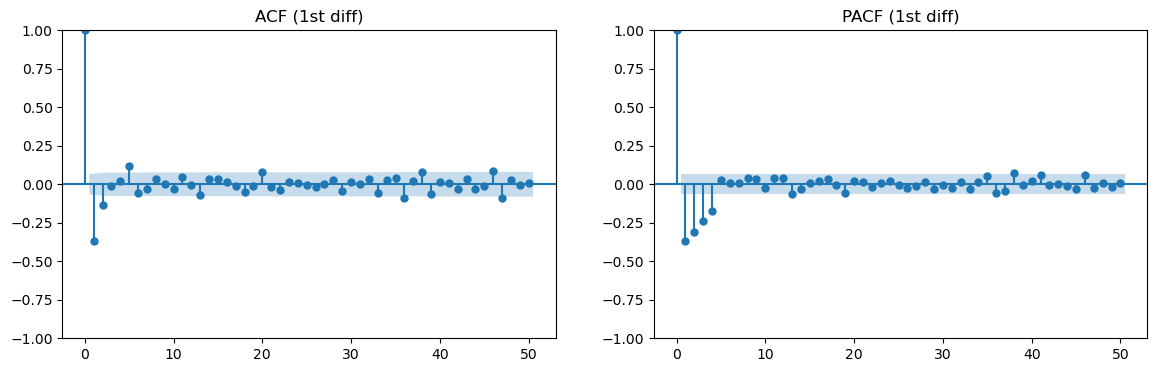

[i] Running auto_arima (это может занять время)...
[i] auto_arima selected order: (4, 1, 2)
[i] ARIMA(4, 1, 2) -> RMSE=0.0135, MAE=0.0108


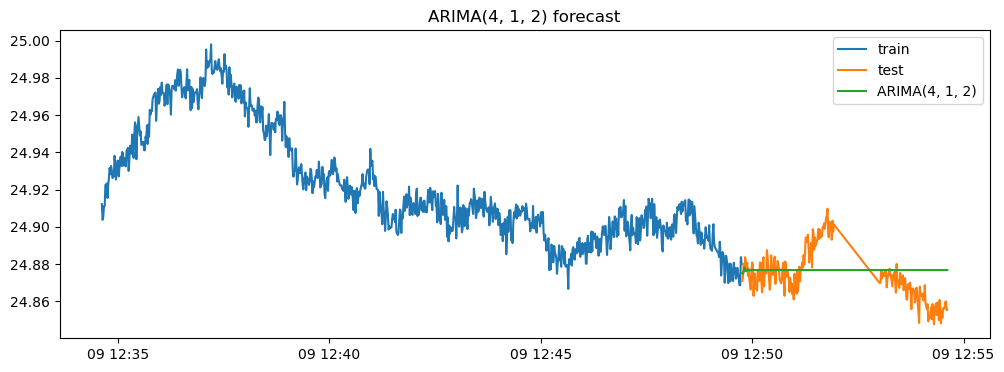

[i] После FE: rows=1084
[i] RandomForest -> RMSE=0.0061, MAE=0.0031


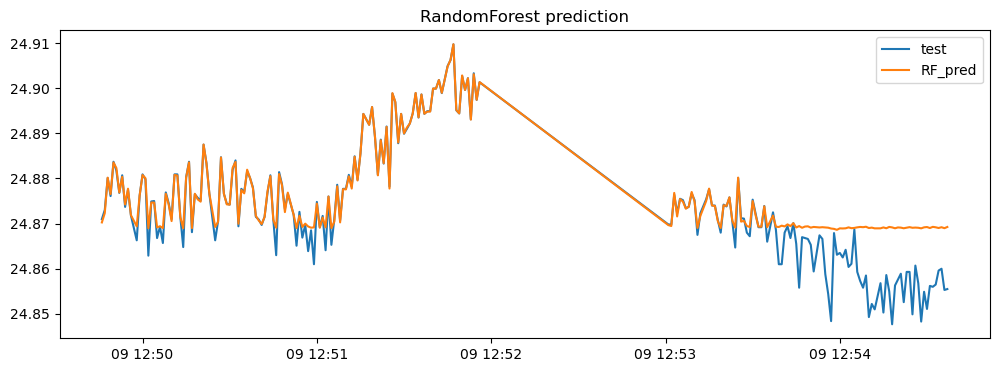

[i] ETNA (RNNModel/DeepAR) недоступна — пропускаем нейросети.

[Итоговые метрики (по RMSE):]
             model      rmse       mae
0     RandomForest  0.006081  0.003089
1  rolling_mean_w5  0.013223  0.010319
2   ARIMA(4, 1, 2)  0.013511  0.010772
3       naive_last  0.014578  0.012105
[i] Метрики сохранены в metrics_summary.csv
[i] Предсказания сохранены в predictions_summary.csv


In [4]:
#Конев Юрий Денисович, РИ-421002
#Homework 2. За временной ряд взял данные термопары промышленного оборудования с экспериментальной установки из датасета SKAB

import os
import csv
import random
import warnings
from typing import Optional

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

from sklearn.ensemble import RandomForestRegressor
from sklearn.metrics import mean_absolute_error, mean_squared_error

import statsmodels.api as sm
from statsmodels.tsa.stattools import adfuller
from statsmodels.graphics.tsaplots import plot_acf, plot_pacf

# Попытка импортировать pmdarima для auto_arima
try:
    import pmdarima as pm
except Exception:
    pm = None

# ETNA (нейросети)
try:
    from etna.datasets import TSDataset
    from etna.transforms import LagTransform, DateFlagsTransform, StandardScalerTransform
    from etna.models import RNNModel, DeepAR
    ETNA_AVAILABLE = True
except Exception:
    ETNA_AVAILABLE = False

# --------------- Конфигурация ---------------
RANDOM_STATE = 42
np.random.seed(RANDOM_STATE)
random.seed(RANDOM_STATE)
warnings.filterwarnings("ignore")
plt.rcParams["figure.figsize"] = (12, 4)

# Путь к CSV 
DATA_PATH = r"C:\Users\sl1ober\Desktop\me\skab_valve_1.csv"

# --------------- Вспомогательные функции ---------------
def rmse(a, b):
    return np.sqrt(mean_squared_error(a, b))

def safe_to_numeric(s: pd.Series) -> pd.Series:
    """Привести серию к числу, заменяя запятую на точку и убирая пробелы."""
    return pd.to_numeric(s.astype(str).str.replace(',', '.').str.strip(), errors='coerce')

def infer_and_read_csv(path: str) -> pd.DataFrame:
    """Попытка прочитать CSV с авто-подбором разделителя и кодировки,
       и корректной разборкой случаев, когда pandas прочитал всё в одну колонку."""
    if not os.path.exists(path):
        raise FileNotFoundError(f"Файл не найден: {path}")

    # Считаем первые N строк как образец для sniff
    sample = ""
    with open(path, 'r', encoding='utf-8', errors='ignore') as f:
        for _ in range(10):
            try:
                sample += next(f)
            except StopIteration:
                break
    try:
        dialect = csv.Sniffer().sniff(sample, delimiters=[',', ';', '\t', '|'])
        sep = dialect.delimiter
    except Exception:
        sep = ';' 
    print(f"[i] Inferred delimiter: '{sep}'")

    try:
        df = pd.read_csv(path, sep=sep, encoding='utf-8', engine='python')
    except Exception as e1:
        print("[i] utf-8 read failed, trying latin1:", e1)
        df = pd.read_csv(path, sep=sep, encoding='latin1', engine='python')

    if df.shape[1] == 1:
        # распарсим вручную split (без заголовка)
        s = df.iloc[:, 0].astype(str)
        splitted = s.str.split(sep, expand=True)
        df = splitted
        # добавим временный header 0..n-1
        df.columns = [f"c{i}" for i in range(df.shape[1])]
    return df

def detect_columns(df: pd.DataFrame) -> (str, Optional[str]):
    """
    Найти колонку с температурой (thermocouple) и колонку с датой
    Возвращает (value_col, date_col_or_None)
    """
    # нормализуем имена колонок в строках
    col_names = [str(c) for c in df.columns]

    # Ищем колонку по имени 'thermocouple' 
    for c in col_names:
        if 'thermocouple' in c.lower():
            return c, _find_date_col(df)

    numeric_candidates = []
    for c in col_names:
        sample = df[c].dropna().astype(str).head(50).str.replace(',', '.').str.strip()
        converted = pd.to_numeric(sample, errors='coerce')
        if converted.notna().sum() >= max(5, len(sample)//2):
            numeric_candidates.append(c)
    if not numeric_candidates:
        raise ValueError("Не удалось определить колонку с числовыми значениями (thermocouple)."
                         " Посмотрите, какие колонки прочитались: " + ", ".join(col_names))
    value_col = numeric_candidates[0]
    date_col = _find_date_col(df)
    return value_col, date_col

def _find_date_col(df: pd.DataFrame) -> Optional[str]:
    """Ищем колонку, содержащую дату/время: простой эвристикой."""
    for c in df.columns:
        s = df[c].astype(str).head(100)
        # ищем шаблон YYYY- or presence of ':' (time)
        if s.str.contains(r"\d{4}-\d{2}-\d{2}").any() or s.str.contains(r"\d{2}:\d{2}:\d{2}").any():
            return c
    return None

# --------------- Загрузка и предобработка ---------------
print("[i] Читаем CSV...")
raw = infer_and_read_csv(DATA_PATH)
print("[i] Прочитано. Колонки:", raw.columns.tolist())

value_col, date_col = detect_columns(raw)
print(f"[i] Выбрали колонку с значениями: '{value_col}'  | колонка с датой: '{date_col}'")

# Создаём столбцы ds (дата/индекс) и y (значение)
df = raw.copy()

# Попробуем привести дату
if date_col is not None:
    df['ds'] = pd.to_datetime(df[date_col].astype(str).str.replace(';', ' '), errors='coerce')
else:
    # если даты нет — создадим числовой индекс
    df['ds'] = pd.RangeIndex(start=0, stop=len(df))

# Приводим y к числу
df['y'] = safe_to_numeric(df[value_col])

# Удаляем строки без y
n_before = len(df)
df = df.dropna(subset=['y']).reset_index(drop=True)
n_after = len(df)
print(f"[i] Удалено строк без y: {n_before - n_after}")

# Если есть ds как datetime — сортируем
if np.issubdtype(df['ds'].dtype, np.datetime64):
    df = df.sort_values('ds').reset_index(drop=True)
else:
    # ds — числовой индекс, оставляем порядок
    df = df.reset_index(drop=True)

print("[i] Превью ряда:")
print(df[['ds', 'y']].head(5))

# --------------- Визуализация ряда (предположения) ---------------
plt.figure()
plt.plot(df['ds'], df['y'], label='Thermocouple')
plt.title("Временной ряд — Thermocouple (эскиз)")
plt.xlabel("time")
plt.ylabel("temperature")
plt.legend()
plt.show()


# --------------- Train/Test split (80/20 по времени) ---------------
n = len(df)
train_size = int(0.8 * n)
train = df.iloc[:train_size].copy().reset_index(drop=True)
test = df.iloc[train_size:].copy().reset_index(drop=True)
print(f"[i] Всего точек: {n}, train: {len(train)}, test: {len(test)}")

# --------------- Выбранная метрика ---------------
# Для задачи регрессии на температуре: RMSE (основная) и MAE (вспомогательная)
print("[i] Метрики: RMSE (основная), MAE (доп.)")

# --------------- Бейзлайны ---------------
# Наивный (last value) и скользящее среднее — аккуратно рассчитываем
baseline_metrics = []

# наивный
if len(train['y']) >= 1:
    naive = np.repeat(train['y'].iloc[-1], len(test))
else:
    naive = np.repeat(df['y'].mean(), len(test))
baseline_metrics.append({'model': 'naive_last', 'rmse': rmse(test['y'], naive), 'mae': mean_absolute_error(test['y'], naive)})

# скользящее среднее с окном w
w = 5
if len(train['y']) >= w:
    rolling_mean_val = train['y'].iloc[-w:].mean()
else:
    rolling_mean_val = train['y'].mean()
rolling = np.repeat(rolling_mean_val, len(test))
baseline_metrics.append({'model': f'rolling_mean_w{w}', 'rmse': rmse(test['y'], rolling), 'mae': mean_absolute_error(test['y'], rolling)})

# визуализация бейзлайнов
plt.figure()
plt.plot(train['ds'], train['y'], label='train')
plt.plot(test['ds'], test['y'], label='test')
plt.plot(test['ds'], naive, label='naive_last')
plt.plot(test['ds'], rolling, label=f'rolling_w{w}')
plt.legend(); plt.title("Baseline predictions"); plt.show()

print("[i] Baseline metrics:")
print(pd.DataFrame(baseline_metrics))

# --------------- Статистический анализ: ADF и ACF/PACF ---------------
print("\n[i] ADF test on train (H0: единичный корень - нестационарность)")
adf_res = adfuller(train['y'].dropna())
print(f"ADF statistic = {adf_res[0]:.4f}, p-value = {adf_res[1]:.4f}")
if adf_res[1] <= 0.05:
    print("=> Ряд, вероятно, стационарен (отклоняем H0).")
else:
    print("=> Ряд нестационарен (не отклоняем H0).")

# ACF/PACF
fig, axes = plt.subplots(1, 2, figsize=(14, 4))
plot_acf(train['y'].dropna(), lags=50, ax=axes[0])
plot_pacf(train['y'].dropna(), lags=50, ax=axes[1])
axes[0].set_title("ACF (train)"); axes[1].set_title("PACF (train)")
plt.show()

# --------------- Преобразования: дифференцирование ---------------
d1 = train['y'].diff().dropna()
print("\n[i] ADF test on 1st difference")
adf_d1 = adfuller(d1)
print(f"ADF statistic = {adf_d1[0]:.4f}, p-value = {adf_d1[1]:.4f}")
fig, axes = plt.subplots(1, 2, figsize=(14, 4))
plot_acf(d1, lags=50, ax=axes[0])
plot_pacf(d1, lags=50, ax=axes[1])
axes[0].set_title("ACF (1st diff)"); axes[1].set_title("PACF (1st diff)")
plt.show()

# --------------- ARIMA (или SARIMA) ---------------
arima_metrics = []
if pm is not None:
    print("[i] Running auto_arima (это может занять время)...")
    try:
        auto = pm.auto_arima(train['y'].dropna(), seasonal=False, trace=False, error_action='ignore', suppress_warnings=True)
        order = auto.order
        print(f"[i] auto_arima selected order: {order}")
    except Exception as e:
        print("[!] auto_arima failed:", e)
        order = (1, 1, 1)
else:
    print("[i] pmdarima not available — using order=(1,1,1)")
    order = (1, 1, 1)

# Обучаем ARIMA
try:
    arima_model = sm.tsa.ARIMA(train['y'], order=order)
    arima_fit = arima_model.fit()
    arima_forecast = arima_fit.forecast(steps=len(test))
    arima_rmse = rmse(test['y'], arima_forecast)
    arima_mae = mean_absolute_error(test['y'], arima_forecast)
    arima_metrics.append({'model': f'ARIMA{order}', 'rmse': arima_rmse, 'mae': arima_mae})
    print(f"[i] ARIMA{order} -> RMSE={arima_rmse:.4f}, MAE={arima_mae:.4f}")
    # визуализация
    plt.figure()
    plt.plot(train['ds'], train['y'], label='train')
    plt.plot(test['ds'], test['y'], label='test')
    plt.plot(test['ds'], arima_forecast, label=f'ARIMA{order}')
    plt.legend(); plt.title(f'ARIMA{order} forecast'); plt.show()
except Exception as e:
    print("[!] ARIMA training/forecast failed:", e)

# --------------- Feature engineering (для классической ML) ---------------
# Копируем исходный df для feature-engineering; используем весь ряд, затем разобьём на train/test по индексам
fe = df.copy()

# Признаки времени (если ds datetime)
if np.issubdtype(fe['ds'].dtype, np.datetime64):
    fe['year'] = fe['ds'].dt.year
    fe['month'] = fe['ds'].dt.month
    fe['day'] = fe['ds'].dt.day

    if 'hour' in dir(fe['ds'].dt):
        try:
            fe['hour'] = fe['ds'].dt.hour
            fe['minute'] = fe['ds'].dt.minute
        except Exception:
            pass
    fe['weekday'] = fe['ds'].dt.weekday
else:
    # если ds числовой индекс
    fe['pos'] = np.arange(len(fe))

# Лаги и скользящие статистики
lags = [1, 2, 3, 5, 10]
windows = [3, 5, 10]
for lg in lags:
    fe[f'lag_{lg}'] = fe['y'].shift(lg)
for w in windows:
    fe[f'roll_mean_{w}'] = fe['y'].rolling(w).mean()
    fe[f'roll_std_{w}'] = fe['y'].rolling(w).std()

# Удаляем строки с NaN 
fe = fe.dropna().reset_index(drop=True)
print(f"[i] После FE: rows={len(fe)}")

# Разделение
test_ds_set = set(test['ds'])
# создаём mask: последние len(test) строк по ds
if np.issubdtype(fe['ds'].dtype, np.datetime64):
    # Возьмём строки, где ds >= min тестовой ds
    min_test_ds = test['ds'].min()
    X_train_fe = fe[fe['ds'] < min_test_ds].copy()
    X_test_fe = fe[fe['ds'] >= min_test_ds].copy()
else:
    # если нет дат, делим по позиции
    split_pos = int(0.8 * len(fe))
    X_train_fe = fe.iloc[:split_pos].copy()
    X_test_fe = fe.iloc[split_pos:].copy()

# Подготавливаем X/y
drop_cols = ['ds', 'y']
X_train = X_train_fe.drop(columns=drop_cols)
y_train = X_train_fe['y']
X_test = X_test_fe.drop(columns=drop_cols)
y_test = X_test_fe['y']

# Убедимся, что все признаки числовые; если есть object — преобразуем/удалим
for c in X_train.columns:
    if not np.issubdtype(X_train[c].dtype, np.number):
        X_train[c] = safe_to_numeric(X_train[c]).fillna(0)
for c in X_test.columns:
    if not np.issubdtype(X_test[c].dtype, np.number):
        X_test[c] = safe_to_numeric(X_test[c]).fillna(0)

# Если какие-то NaN остались — заполним медианой из train
X_train = X_train.fillna(X_train.median())
X_test = X_test.fillna(X_train.median())

# Обучаем RandomForest
rf_metrics = []
try:
    rf = RandomForestRegressor(n_estimators=200, random_state=RANDOM_STATE, n_jobs=-1)
    rf.fit(X_train, y_train)
    rf_pred = rf.predict(X_test)
    rf_rmse = rmse(y_test, rf_pred)
    rf_mae = mean_absolute_error(y_test, rf_pred)
    rf_metrics.append({'model': 'RandomForest', 'rmse': rf_rmse, 'mae': rf_mae})
    print(f"[i] RandomForest -> RMSE={rf_rmse:.4f}, MAE={rf_mae:.4f}")
    # визуализация
    plt.figure()
    plt.plot(X_test_fe['ds'], y_test.values, label='test')
    plt.plot(X_test_fe['ds'], rf_pred, label='RF_pred')
    plt.legend(); plt.title('RandomForest prediction'); plt.show()
except Exception as e:
    print("[!] RandomForest failed:", e)

# --------------- Нейросетевые модели (ETNA) ---------------
etna_metrics = []
if ETNA_AVAILABLE:
    try:
        print("[i] ETNA available -> preparing dataset and models (RNNModel, DeepAR)")
        # Преобразуем df к формату TSDataset
        # Для корректной работы ETNA нужен freq — попытаемся угадать частоту по diff дат
        ds = df[['ds', 'y']].copy()
        ds = ds.rename(columns={'ds': 'timestamp'})
        ds['timestamp'] = pd.to_datetime(ds['timestamp'], errors='coerce')
        ds = ds.set_index('timestamp')
        guessed_freq = pd.infer_freq(ds.index[:50])  # может вернуть None
        if guessed_freq is None:
            # fallback: используем 'D'
            guessed_freq = 'D'
        dataset = TSDataset.to_dataset(df.rename(columns={'ds': 'timestamp'}).set_index('timestamp'))
        ts = TSDataset(dataset, freq=guessed_freq)
        # трансформы
        transforms = [LagTransform(in_column='y', lags=[1,2,3,5,10]), DateFlagsTransform(), StandardScalerTransform(in_column='y')]
        ts.fit_transform(transforms)
        # RNN
        rnn = RNNModel(in_chunk_len=30, out_chunk_len=len(test), random_state=RANDOM_STATE)
        rnn.fit(ts)
        rnn_forecast = rnn.forecast(ts)
        # DeepAR
        de = DeepAR(in_chunk_len=30, out_chunk_len=len(test), random_state=RANDOM_STATE)
        de.fit(ts)
        de_forecast = de.forecast(ts)

        print("[i] ETNA models trained (предсказания нужно привести к test indices вручную).")
    except Exception as e:
        print("[!] ETNA section failed:", e)
else:
    print("[i] ETNA (RNNModel/DeepAR) недоступна — пропускаем нейросети.")

# --------------- Сбор метрик и сравнение ---------------
all_metrics = []
all_metrics.extend(baseline_metrics)
all_metrics.extend(arima_metrics)
all_metrics.extend(rf_metrics)
# etna_metrics можно добавить аналогично

metrics_df = pd.DataFrame(all_metrics).sort_values('rmse').reset_index(drop=True)
print("\n[Итоговые метрики (по RMSE):]")
print(metrics_df)

# Сохраняем результаты
metrics_df.to_csv("metrics_summary.csv", index=False)
print("[i] Метрики сохранены в metrics_summary.csv")

# Сохраняем предсказания (простые модели)
out = test[['ds','y']].copy().reset_index(drop=True)
out['naive'] = naive
out['rolling_mean'] = rolling
if 'arima_forecast' in locals():
    out['arima'] = np.asarray(arima_forecast)
if 'rf_pred' in locals():
    # если FE-тест отличается по размерности — приведём временные метки из X_test_fe
    # Подставим RF прогнозы по датам X_test_fe
    # Создадим вспомогательный DF
    rf_df = pd.DataFrame({'ds': X_test_fe['ds'].values, 'rf_pred': rf_pred})
    # Попытаемся смёрджить по датам; если ds в тесте совпадают, то merge даст заполнение
    out = out.merge(rf_df, on='ds', how='left')
out.to_csv("predictions_summary.csv", index=False)
print("[i] Предсказания сохранены в predictions_summary.csv")